In [2]:
!pip install -U albumentations

  Using cached albumentations-1.3.1-py3-none-any.whl (125 kB)
  Using cached qudida-0.0.4-py3-none-any.whl (3.5 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 MB 175.9 kB/s eta 0:00:00m eta 0:00:010:24:21


In [88]:
import random
import os

import cv2
from matplotlib import pyplot as plt

import albumentations as A
import numpy as np

from PIL import Image


In [89]:
transform_resize = A.Compose([
    A.Resize(width=128, height=128),  # You can adjust the desired output size here
])

transform = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Resize(width=128, height=128),  # You can adjust the desired output size here
])

In [90]:
def extract_filename_from_path(file_path):
    # Get the base name of the file from the path
    file_name = os.path.basename(file_path)

    # Split the file name and extension
    name, ext = os.path.splitext(file_name)

    return name

In [91]:
def create_directory_if_not_exists(directory_path):
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)
        print(f"Directory created: {directory_path}")
    else:
        print(f"Directory already exists: {directory_path}")

In [92]:
# this function takes two image and plots it side-by-side for comparison
def comparison(actual_image, transformed_image, titles=None):
    if titles == None:
        titles = ['Actual Image', 'Transformed Image']
        
    fig, ax = plt.subplots(1, 2, figsize=(17, 17))
    ax[0].set_title(titles[0])
    if len(actual_image.shape) == 2:
        ax[0].imshow(actual_image, cmap='gray')
    else:
        ax[0].matshow(actual_image)
    ax[0].axis('off')

    ax[1].set_title(titles[1])
    if len(transformed_image.shape) == 2:
        ax[1].imshow(transformed_image, cmap='gray')
    else:
        ax[1].matshow(transformed_image)
    ax[1].axis('off')
    plt.show()

In [96]:
# path to original images and masks
IMAGES = 'Oil_Spill_Detection _Dataset/train/images'
MASKS = 'Oil_Spill_Detection _Dataset/train/labels'

# path to augmented images and masks
AUGMENTED_IMAGES = 'Oil_Spill_Detection _Dataset/augmented/train/images'
AUGMENTED_MASKS = 'Oil_Spill_Detection _Dataset/augmented/train/labels'

# create directories for augmented
create_directory_if_not_exists(AUGMENTED_IMAGES)
create_directory_if_not_exists(AUGMENTED_MASKS)

IMAGES_list = os.listdir(IMAGES)
MASKS_list = os.listdir(MASKS)
print(f"{len(IMAGES_list)} - {len(MASKS_list)}")

Directory created: Oil_Spill_Detection _Dataset/augmented/train/images
Directory created: Oil_Spill_Detection _Dataset/augmented/train/labels
1002 - 1002


In [97]:
IMAGES_list = sorted(IMAGES_list)
MASKS_list = sorted(MASKS_list)

def data_augmentation(ith_iteration=1, number_of_comparisons_to_plot=5):
    print('ith_iteration = '+str(ith_iteration))
    
    comparisons_plotted = 1
    
    
    for image, mask in (zip(IMAGES_list, MASKS_list)):

    #     retrieve image and mask filenames. To be used when saving both eg
        image_name = extract_filename_from_path(image) # eg img_0001.jpg
        mask_name = extract_filename_from_path(mask) # eg img_0001.png

    #     get full path to image and mask
        filepath_image = os.path.join(IMAGES, image)
        filepath_mask = os.path.join(MASKS, mask)
        

        tmp_image_name = f"{image_name}_0.png"
        tmp_mask_name = f"{mask_name}_0.png"

        image_path = os.path.join(AUGMENTED_IMAGES, tmp_image_name)
        mask_path = os.path.join(AUGMENTED_MASKS, tmp_mask_name)


        image = Image.open(filepath_image) # open image
        image_array = np.array(image) # convert image to np.array

        mask = Image.open(filepath_mask) # open mask
        mask_array = np.array(mask) # convert mask to np.array
    #     print(image_array.shape, mask_array.shape)

    #     perform resizing only
        transformed_resized = transform_resize(image=image_array, mask=mask_array)
        transformed_image_resized = transformed_resized['image']
        transformed_mask_resized = transformed_resized['mask']

        # Convert the augmented image back to PIL format
        augmented_image_pil_resized = Image.fromarray(np.uint8(transformed_image_resized))
        augmented_mask_pil_resized = Image.fromarray(np.uint8(transformed_mask_resized))
    
    #     save original image and mask before augmentation
        augmented_image_pil_resized.save(image_path)
        augmented_mask_pil_resized.save(mask_path)

    #     perform augmentation
        transformed = transform(image=image_array, mask=mask_array)
        transformed_image = transformed['image']
        transformed_mask = transformed['mask']

        # Convert the augmented image back to PIL format
        augmented_image_pil = Image.fromarray(np.uint8(transformed_image))
        augmented_mask_pil = Image.fromarray(np.uint8(transformed_mask))

        if comparisons_plotted <= number_of_comparisons_to_plot:
            print('\n +++++++++++++++++ ORIGINAL IMAGE (' +image_name+') VS AUGMENTED IMAGE (' +mask_name+') +++++++++++++++++++++')
            comparison(image_array, transformed_image)
#             comparison(mask_array, transformed_mask, titles=['Actual Mask', 'Transformed Mask'])
            comparisons_plotted += 1


        

        tmp_image_name = f"{image_name}_{ith_iteration}.png"
        tmp_mask_name = f"{mask_name}_{ith_iteration}.png"

        image_path = os.path.join(AUGMENTED_IMAGES, tmp_image_name)
        mask_path = os.path.join(AUGMENTED_MASKS, tmp_mask_name)
        
        augmented_image_pil.save(image_path)
        augmented_mask_pil.save(mask_path)




 =========== LOOP 0 =============
ith_iteration = 1

 +++++++++++++++++ ORIGINAL IMAGE (img_0001) VS AUGMENTED IMAGE (img_0001) +++++++++++++++++++++


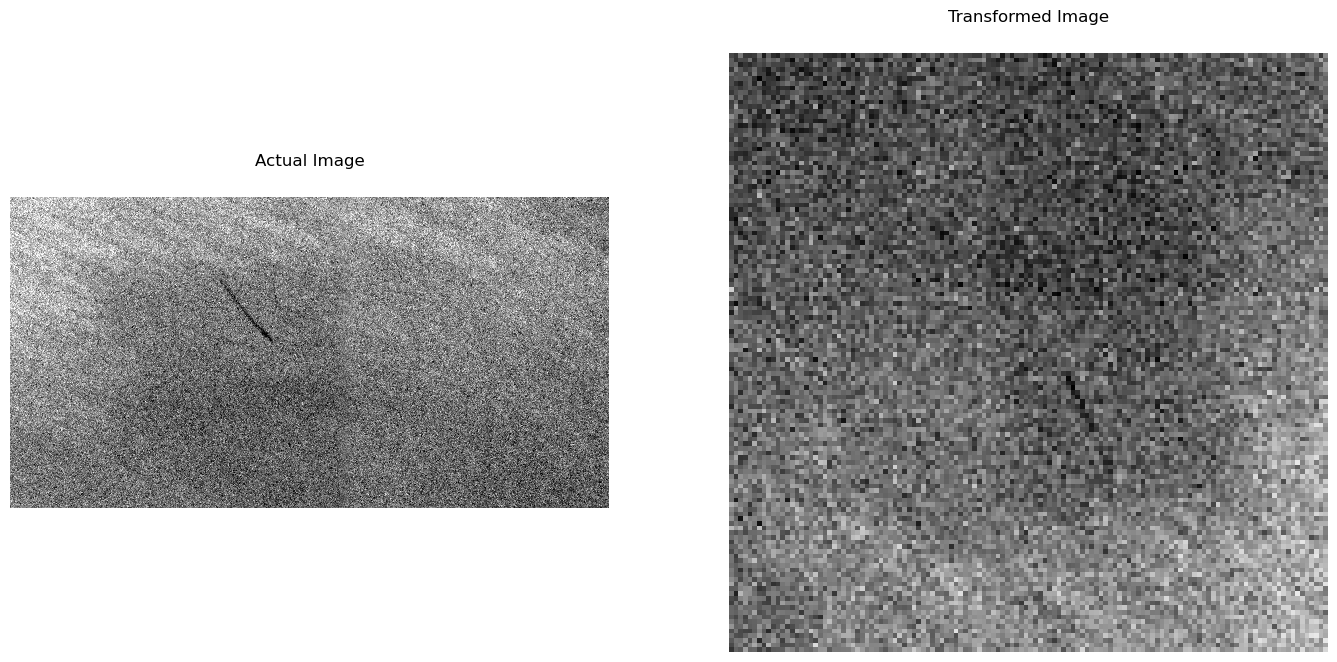




 =========== LOOP 1 =============
ith_iteration = 2

 +++++++++++++++++ ORIGINAL IMAGE (img_0001) VS AUGMENTED IMAGE (img_0001) +++++++++++++++++++++


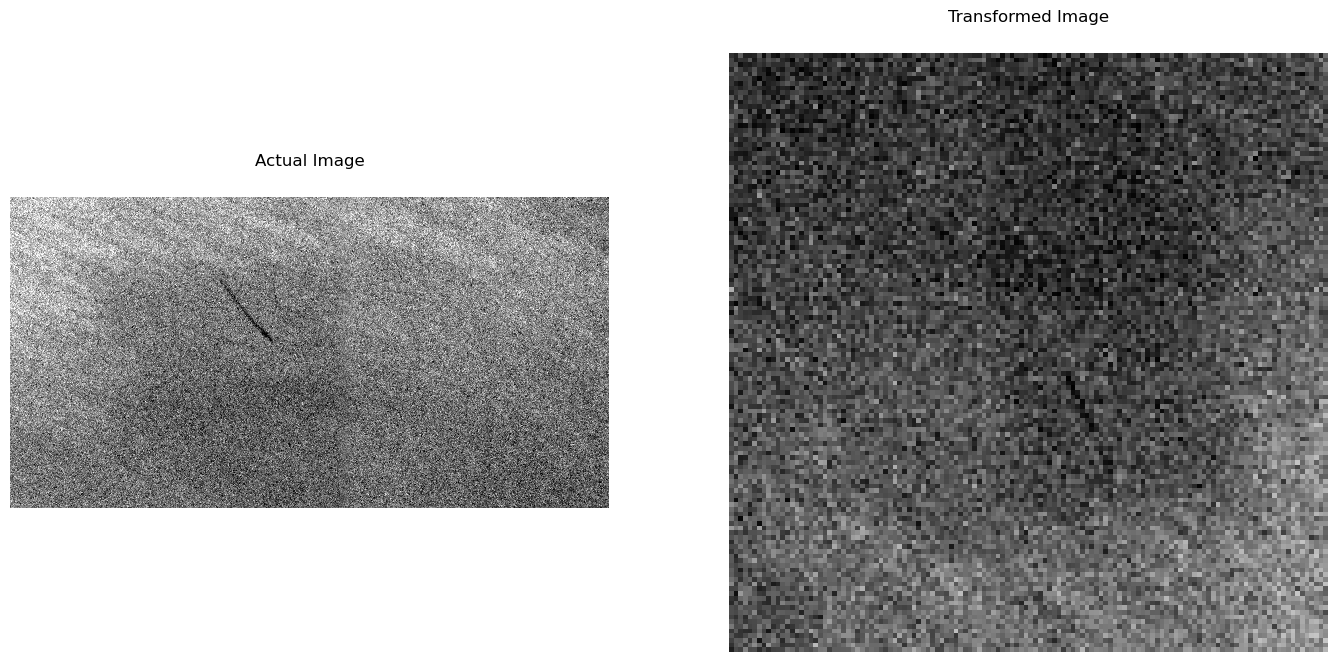

In [98]:
for i in range(2):
    print('\n\n\n =========== LOOP ' + str(i) + ' =============')
    data_augmentation(ith_iteration=i+1, number_of_comparisons_to_plot=1)